In [1]:
import os

# Fixes for loading datasets on windows
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["DATASETS_VERBOSITY"] = "error"
os.environ["WANDB_DISABLED"] = "true" # Keeps logs clean

import numpy as np
import torch
import evaluate
from datasets import load_dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    DataCollatorWithPadding
)

print("Libraries loaded safely. GPU Available:", torch.cuda.is_available())

Libraries loaded safely. GPU Available: True


In [2]:
print("Bypassing Hugging Face Hub and downloading raw JSONL files from GitHub...")

# URL extracted from the author's deprecated script
base_url = "https://raw.githubusercontent.com/fhamborg/NewsMTSC/6b838e00f54423c253806327a0ae24dbffa24c9e/NewsSentiment/experiments/default/datasets/newsmtsc-rw-hf/"

data_files = {
    "train": base_url + "train.jsonl",
    "validation": base_url + "dev.jsonl",
    "test": base_url + "test.jsonl"
}

# Use the native, secure JSON loader
dataset = load_dataset("json", data_files=data_files)

print("\n--- Dataset Splits ---")
print(dataset)

print("\n--- Sample Record From Training Set ---")
print(dataset['train'][0])

Bypassing Hugging Face Hub and downloading raw JSONL files from GitHub...

--- Dataset Splits ---
DatasetDict({
    train: Dataset({
        features: ['mention', 'polarity', 'from', 'to', 'sentence', 'id'],
        num_rows: 8739
    })
    validation: Dataset({
        features: ['mention', 'polarity', 'from', 'to', 'sentence', 'id'],
        num_rows: 343
    })
    test: Dataset({
        features: ['mention', 'polarity', 'from', 'to', 'sentence', 'id'],
        num_rows: 803
    })
})

--- Sample Record From Training Set ---
{'mention': 'Winner', 'polarity': 0, 'from': 0, 'to': 6, 'sentence': 'Winner wrote that she had a 30-minute private meeting with the Republican lawmaker’s state policy director.', 'id': 'allsides_1000_401_25_Reality Leigh Winner_0_6'}


In [3]:
model_name = "distilroberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_absa_function(examples):
    tokenized_inputs = tokenizer(
        examples["sentence"], 
        examples["mention"], 
        truncation=True, 
        max_length=128 
    )
    # Shift labels: -1, 0, 1 -> 0, 1, 2
    tokenized_inputs["labels"] = [label + 1 for label in examples["polarity"]]
    return tokenized_inputs

print("Tokenizing entire dataset...")
tokenized_datasets = dataset.map(tokenize_absa_function, batched=True)
print("Tokenization Complete!")

Tokenizing entire dataset...


Map:   0%|          | 0/8739 [00:00<?, ? examples/s]

Map:   0%|          | 0/343 [00:00<?, ? examples/s]

Map:   0%|          | 0/803 [00:00<?, ? examples/s]

Tokenization Complete!


In [4]:
def model_init():
    return AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return f1_metric.compute(predictions=predictions, references=labels, average="macro")

print("Model factory and metrics engine successfully initialized.")

Model factory and metrics engine successfully initialized.


In [6]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="../checkpoints_hyperparam_search",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_steps=0,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True,
    logging_steps=50,
)

trainer = Trainer(
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
    model_init=model_init,
    data_collator=data_collator, 
)

print("Trainer configured for hyperparameter search.")

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | Details
----------------------------+------------+--------
lm_head.layer_norm.weight   | UNEXPECTED |        
roberta.pooler.dense.weight | UNEXPECTED |        
lm_head.dense.bias          | UNEXPECTED |        
lm_head.bias                | UNEXPECTED |        
lm_head.layer_norm.bias     | UNEXPECTED |        
roberta.pooler.dense.bias   | UNEXPECTED |        
lm_head.dense.weight        | UNEXPECTED |        
classifier.out_proj.weight  | MISSING    |        
classifier.dense.weight     | MISSING    |        
classifier.out_proj.bias    | MISSING    |        
classifier.dense.bias       | MISSING    |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainer configured for hyperparameter search.


In [7]:
def custom_hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 2e-5, 2e-4, log=True),
        "num_train_epochs": trial.suggest_int("num_train_epochs", 2, 4),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [16, 32, 64]),
        "weight_decay": trial.suggest_float("weight_decay", 0.01, 0.2),
        "warmup_steps": trial.suggest_int("warmup_steps", 0, 200),
    }

print("Starting Custom Optuna Hyperparameter Search V2...")

best_run = trainer.hyperparameter_search(
    direction="maximize", 
    backend="optuna", 
    n_trials=50,
    hp_space=custom_hp_space,
    storage="sqlite:///thesis_hyperparameters.db", 
    study_name="newsmtsc_optimization_v2", 
    load_if_exists=True
)

Starting Custom Optuna Hyperparameter Search V2...


[I 2026-08-20 20:37:08,150] A new study created in RDB with name: newsmtsc_optimization_v2


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | Details
----------------------------+------------+--------
lm_head.layer_norm.weight   | UNEXPECTED |        
roberta.pooler.dense.weight | UNEXPECTED |        
lm_head.dense.bias          | UNEXPECTED |        
lm_head.bias                | UNEXPECTED |        
lm_head.layer_norm.bias     | UNEXPECTED |        
roberta.pooler.dense.bias   | UNEXPECTED |        
lm_head.dense.weight        | UNEXPECTED |        
classifier.out_proj.weight  | MISSING    |        
classifier.dense.weight     | MISSING    |        
classifier.out_proj.bias    | MISSING    |        
classifier.dense.bias       | MISSING    |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1
1,0.508307,0.465644,0.812779
2,0.377847,0.401926,0.852245


...

[I 2026-08-20 21:04:51,708] Trial 48 pruned. 


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | Details
----------------------------+------------+--------
lm_head.layer_norm.weight   | UNEXPECTED |        
roberta.pooler.dense.weight | UNEXPECTED |        
lm_head.dense.bias          | UNEXPECTED |        
lm_head.bias                | UNEXPECTED |        
lm_head.layer_norm.bias     | UNEXPECTED |        
roberta.pooler.dense.bias   | UNEXPECTED |        
lm_head.dense.weight        | UNEXPECTED |        
classifier.out_proj.weight  | MISSING    |        
classifier.dense.weight     | MISSING    |        
classifier.out_proj.bias    | MISSING    |        
classifier.dense.bias       | MISSING    |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1
1,0.568493,0.470248,0.818189


[I 2026-08-20 21:05:07,890] Trial 49 pruned. 


In [9]:
print("--- Hyperparameter Search Complete ---")
print(f"Best Run F1 Score: {best_run.objective}")
print("Best Hyperparameters found by Optuna:")
for key, value in best_run.hyperparameters.items():
    print(f"  {key}: {value}")

--- Hyperparameter Search Complete ---
Best Run F1 Score: 0.8610142050908584
Best Hyperparameters found by Optuna:
  learning_rate: 2.6671030576600103e-05
  num_train_epochs: 4
  per_device_train_batch_size: 16
  weight_decay: 0.036762735036943384
  warmup_steps: 58


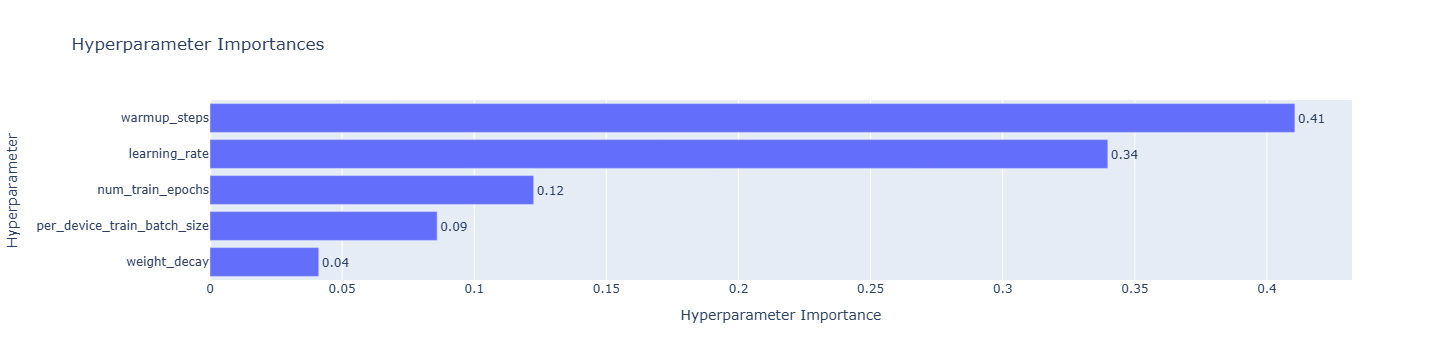

In [1]:
import optuna
import optuna.visualization as vis

study = optuna.load_study(
    study_name="newsmtsc_optimization_v2", 
    storage="sqlite:///thesis_hyperparameters.db"
)

fig_importance = vis.plot_param_importances(study)
fig_importance.show()
fig_importance.write_image("optuna_param_importance.png", scale=2)

fig_history = vis.plot_optimization_history(study)
fig_history.write_image("optuna_optimization_history.png", scale=2)

In [2]:
import optuna
import pandas as pd

study = optuna.load_study(
    study_name="newsmtsc_optimization_v2", 
    storage="sqlite:///thesis_hyperparameters.db"
)

df = study.trials_dataframe()

df_clean = df.drop(columns=["datetime_start", "datetime_complete", "system_attrs_grid_id"], errors="ignore")

df_clean.to_csv("optuna_v2_results.csv", index=False)